# Trading Strategy V2

**Improvements over V1:**
1. Expanded factor universe — multi-horizon momentum, Bollinger z-scores, idiosyncratic momentum
2. Horizon-aligned IC evaluation — screen against 15-day forward returns
3. IC-IR ranking + redundancy removal via greedy correlation-capped selection
4. IC-IR weighted composite score
5. Longer hold (15d), narrower baskets (10%), higher leverage (3×), drawdown protection
6. Proper walk-forward temporal split (train < 2012, test ≥ 2012)

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import spearmanr
import warnings
warnings.filterwarnings('ignore')

df = pd.read_csv('df_train.csv')
df['date'] = pd.to_datetime(df['date'])
df = df.sort_values(['symbol', 'date']).reset_index(drop=True)
split_date = pd.Timestamp('2012-01-01')
print(f"Shape: {df.shape}, Symbols: {df['symbol'].nunique()}, Dates: {df['date'].nunique()}")

Shape: (100600, 7), Symbols: 100, Dates: 1006


## Phase 1a: Original Momentum Factors (V1)

In [2]:
def add_momentum_factors(data):
    d = data.copy().sort_values(['symbol', 'date'])
    gp = d.groupby('symbol')['close']
    d['ret'] = gp.pct_change()
    for w in [5, 10, 20, 60]:
        d[f'mom_{w}d'] = gp.pct_change(w)
        d[f'mom_{w}d_mean'] = d.groupby('symbol')['ret'].transform(lambda s, w=w: s.rolling(w, min_periods=w).mean())
    return d.sort_values(['date', 'symbol']).reset_index(drop=True)

df_mom = add_momentum_factors(df)
print(f"After momentum: {df_mom.shape}")

After momentum: (100600, 16)


## Phase 1b: Original Volatility / Custom Factors (V1)

In [3]:
def add_vol_factors(data):
    d = data.copy().sort_values(['symbol', 'date'])
    gp = d.groupby('symbol')['close']
    gh = d.groupby('symbol')['high']
    gl = d.groupby('symbol')['low']
    if 'ret' not in d.columns:
        d['ret'] = gp.pct_change()
    gr = d.groupby('symbol')['ret']

    for w in [5, 10, 20, 60]:
        d[f'vol_std_{w}d'] = gr.transform(lambda s, w=w: s.rolling(w, min_periods=w).std())
        d[f'vol_skew_{w}d'] = gr.transform(lambda s, w=w: s.rolling(w, min_periods=w).skew())
        d[f'vol_kurt_{w}d'] = gr.transform(lambda s, w=w: s.rolling(w, min_periods=w).kurt())

    d['factor1'] = gh.transform(lambda s: s.rolling(60,60).max()) / gl.transform(lambda s: s.rolling(60,60).min()) - 1
    d['factor2'] = gh.transform(lambda s: s.rolling(60,60).apply(lambda x: np.mean(np.abs(x-x.mean())),raw=False)) / d['close']

    r5 = gp.pct_change(5)
    d['factor4'] = r5.groupby(d['symbol']).transform(lambda s: s.rolling(60,20).skew())
    r10 = gp.pct_change(10)
    d['factor4_10d'] = r10.where(r10>0).groupby(d['symbol']).transform(lambda s: s.rolling(60,20).skew())

    d['factor5_30'] = d.groupby('symbol', group_keys=False).apply(lambda g: g['close'].shift(1).rolling(30,30).corr(g['volume'])).values
    d['factor5_10'] = d.groupby('symbol', group_keys=False).apply(lambda g: g['close'].shift(1).rolling(10,10).corr(g['volume'])).values

    for name, p in [('factor7',7),('factor8',20),('factor10',30),('factor9',60)]:
        rk = gp.pct_change(p)
        d[name] = rk.groupby(d['symbol']).transform(lambda s: s.rolling(60,60).min())

    return d.sort_values(['date','symbol']).reset_index(drop=True)

df_vol = add_vol_factors(df_mom)
print(f"After vol factors: {df_vol.shape}")

After vol factors: (100600, 38)


In [32]:
df_vol[df_vol["date"] >= "2010-05-01"]

,date,symbol,open,close,low,high,volume,ret,mom_5d,mom_5d_mean,...,factor1,factor2,factor4,factor4_10d,factor5_30,factor5_10,factor7,factor8,factor10,factor9
8200,2010-05-03,ACTS,13.73,13.83,13.73,13.73,5545.253,0.006550,-0.007179,-0.001375,...,0.093842,0.020087,0.145853,0.636581,-0.208183,0.483311,-0.062331,-0.077333,NaN,NaN
8201,2010-05-03,AMWD,7.33,7.33,7.33,7.33,73916.786,-0.021362,-0.072152,-0.014733,...,0.250765,0.044172,-0.005755,0.283194,-0.313193,-0.170709,-0.076726,-0.142857,NaN,NaN
8202,2010-05-03,ARV,18.00,17.97,18.00,18.00,49671.561,-0.001667,0.089091,0.017391,...,0.193082,0.038835,0.372758,0.730895,-0.415893,-0.543576,-0.117092,-0.141732,NaN,NaN
8203,2010-05-03,BBY,3.01,3.00,3.01,3.01,41938.326,-0.003322,0.000000,0.000018,...,0.164794,0.024333,0.331988,0.868943,0.110284,0.461035,-0.069686,-0.072664,NaN,NaN
8204,2010-05-03,BCDM,18.35,18.35,18.35,18.35,3698.032,-0.027041,-0.026525,-0.005295,...,0.176505,0.027699,-0.007081,1.510677,-0.054363,-0.155344,-0.063509,-0.078807,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
100595,2013-12-31,XTG,20.15,20.00,20.15,20.15,42044.703,0.000000,0.078167,0.015216,...,0.411064,0.077996,0.277437,0.730437,0.198378,-0.229759,-0.068546,-0.050847,-0.059861,-0.242392
100596,2013-12-31,YPN,14.94,14.82,14.94,14.94,29030.106,0.019959,0.091311,0.017657,...,0.440694,0.064555,0.172568,0.158888,0.154854,-0.231451,-0.038924,-0.069272,-0.094209,-0.024390
100597,2013-12-31,YRD,3.40,3.39,3.40,3.40,11778.336,0.018018,0.069401,0.013592,...,0.446809,0.070423,0.655594,0.532045,0.206631,-0.334602,-0.057576,-0.062992,-0.043137,-0.338889
100598,2013-12-31,YVNL,4.25,4.24,4.25,4.25,6431.843,0.014354,0.107050,0.020834,...,0.949541,0.120844,0.554295,0.728912,-0.142304,-0.264046,-0.055319,-0.174721,-0.195652,-0.165414


## Phase 1c: NEW Factor Families

**A.** Multi-horizon momentum (30d, 42d, 126d)

**B.** Bollinger z-scores: $z = (\log P - \text{MA}_K) / \sigma_K$ for K=21,42,63

**C.** Idiosyncratic momentum: subtract cross-sectional mean to isolate stock-specific signal

In [6]:
def add_new_factors(data):
    d = data.copy().sort_values(['symbol','date'])
    gp = d.groupby('symbol')['close']

    for w in [30, 42, 126]:
        d[f'mom_{w}d'] = gp.pct_change(w)

    d['log_price'] = np.log(d['close'])
    glp = d.groupby('symbol')['log_price']
    for w in [21, 42, 63]:
        ma = glp.transform(lambda s, w=w: s.rolling(w, min_periods=w).mean())
        sd = glp.transform(lambda s, w=w: s.rolling(w, min_periods=w).std())
        d[f'zscore_{w}d'] = (d['log_price'] - ma) / sd
    d.drop(columns=['log_price'], inplace=True)

    for w in [30, 42, 60]:
        col = f'mom_{w}d'
        xs_mean = d.groupby('date')[col].transform('mean')
        d[f'idio_mom_{w}d'] = d[col] - xs_mean

    return d.sort_values(['date','symbol']).reset_index(drop=True)

df_factor = add_new_factors(df_vol)

base_cols = ['date','symbol','open','close','low','high','volume','ret']
all_factor_cols = [c for c in df_factor.columns if c not in base_cols]
print(f"Total factors: {len(all_factor_cols)}")
print(all_factor_cols)

Total factors: 39
['mom_5d', 'mom_5d_mean', 'mom_10d', 'mom_10d_mean', 'mom_20d', 'mom_20d_mean', 'mom_60d', 'mom_60d_mean', 'vol_std_5d', 'vol_skew_5d', 'vol_kurt_5d', 'vol_std_10d', 'vol_skew_10d', 'vol_kurt_10d', 'vol_std_20d', 'vol_skew_20d', 'vol_kurt_20d', 'vol_std_60d', 'vol_skew_60d', 'vol_kurt_60d', 'factor1', 'factor2', 'factor4', 'factor4_10d', 'factor5_30', 'factor5_10', 'factor7', 'factor8', 'factor10', 'factor9', 'mom_30d', 'mom_42d', 'mom_126d', 'zscore_21d', 'zscore_42d', 'zscore_63d', 'idio_mom_30d', 'idio_mom_42d', 'idio_mom_60d']


## Phase 2: Evaluate Factors at Different Horizon 

Screen on **IC-IR** (consistency), not just raw IC (magnitude).

## 15-day IC & IC-IR Results

In [12]:
def evaluate_factor_rank_ic(data, factor_cols, forward_days=15):
    d = data.copy().sort_values(['symbol','date'])
    d['fwd_ret'] = d.groupby('symbol')['close'].shift(-forward_days) / d['close'] - 1.0
    records = []
    for dt, cross in d.groupby('date'):
        for f in factor_cols:
            v = cross[[f,'fwd_ret']].dropna()
            ic = v[f].corr(v['fwd_ret'], method='spearman') if len(v)>=10 else np.nan
            records.append({'date':dt, 'factor':f, 'ic':ic})

    ic_df = pd.DataFrame(records)
    summary = ic_df.groupby('factor').agg(
        mean_ic=('ic','mean'), std_ic=('ic','std'), n=('ic','count')).reset_index()
    summary['ic_ir'] = summary['mean_ic'] / summary['std_ic']
    summary['abs_ic_ir'] = summary['ic_ir'].abs()
    return ic_df, summary.sort_values('abs_ic_ir', ascending=False).reset_index(drop=True)

df_factor_train = df_factor[df_factor['date'] < split_date].copy()
ic_daily, ic_summary = evaluate_factor_rank_ic(df_factor_train, all_factor_cols, forward_days=15)

print("=== Top 20 factors by |IC-IR| (15-day forward) ===")
print(ic_summary[['factor','mean_ic','std_ic','ic_ir']].head(20).to_string(index=False))

=== Top 20 factors by |IC-IR| (15-day forward) ===
      factor   mean_ic   std_ic     ic_ir
    mom_126d -0.175285 0.118627 -1.477611
     mom_42d -0.161526 0.158548 -1.018781
idio_mom_42d -0.161526 0.158548 -1.018781
idio_mom_30d -0.160692 0.157857 -1.017962
     mom_30d -0.160692 0.157857 -1.017962
     factor9 -0.155700 0.165319 -0.941815
     mom_60d -0.143596 0.158757 -0.904501
idio_mom_60d -0.143596 0.158757 -0.904501
mom_60d_mean -0.138907 0.162877 -0.852835
     mom_20d -0.111913 0.156666 -0.714340
  zscore_63d -0.110008 0.157324 -0.699248
mom_20d_mean -0.109545 0.157207 -0.696821
    factor10 -0.111926 0.169866 -0.658907
  zscore_42d -0.088649 0.154276 -0.574614
     factor8 -0.088165 0.183114 -0.481474
     factor7 -0.080335 0.224981 -0.357076
vol_skew_20d -0.043071 0.134387 -0.320502
 factor4_10d  0.044659 0.150593  0.296553
vol_kurt_60d  0.035778 0.144528  0.247551
vol_skew_60d -0.028643 0.119051 -0.240592


## Phase 3: Redundancy Removal — Greedy Selection with ρ < 0.6 Cap

In [13]:
def compute_factor_corr(data, factor_cols):
    n = len(factor_cols)
    corr_sum = np.zeros((n,n))
    counts = np.zeros((n,n))
    for dt, cross in data.groupby('date'):
        vals = cross[factor_cols].values
        for i in range(n):
            for j in range(i+1, n):
                mask = np.isfinite(vals[:,i]) & np.isfinite(vals[:,j])
                if mask.sum() >= 10:
                    rho, _ = spearmanr(vals[mask,i], vals[mask,j])
                    if np.isfinite(rho):
                        corr_sum[i,j] += rho; corr_sum[j,i] += rho
                        counts[i,j] += 1; counts[j,i] += 1
    counts[counts==0] = 1
    avg = corr_sum / counts
    np.fill_diagonal(avg, 1.0)
    return pd.DataFrame(avg, index=factor_cols, columns=factor_cols)

candidates = ic_summary[ic_summary['abs_ic_ir'] >= 0.05]['factor'].tolist()
print(f"Candidates (|IC-IR|>=0.05): {len(candidates)}")

factor_corr = compute_factor_corr(df_factor_train, candidates)

def greedy_select(ic_df, corr_mat, max_corr=0.6, max_factors=8):
    selected = []
    for _, row in ic_df.sort_values('abs_ic_ir', ascending=False).iterrows():
        f = row['factor']
        if f not in corr_mat.index: continue
        if selected and corr_mat.loc[f, selected].abs().max() > max_corr: continue
        selected.append(f)
        if len(selected) >= max_factors: break
    return selected

selected_factors = greedy_select(ic_summary, factor_corr)

print(f"\nSelected {len(selected_factors)} factors:")
for f in selected_factors:
    r = ic_summary[ic_summary['factor']==f].iloc[0]
    print(f"  {f:25s}  IC={r['mean_ic']:+.4f}  IC-IR={r['ic_ir']:+.3f}")
print(f"\nPairwise correlations:")
print(factor_corr.loc[selected_factors, selected_factors].round(2))

Candidates (|IC-IR|>=0.05): 37

Selected 8 factors:
  mom_126d                   IC=-0.1753  IC-IR=-1.478
  mom_42d                    IC=-0.1615  IC-IR=-1.019
  factor9                    IC=-0.1557  IC-IR=-0.942
  mom_20d                    IC=-0.1119  IC-IR=-0.714
  factor8                    IC=-0.0882  IC-IR=-0.481
  vol_skew_20d               IC=-0.0431  IC-IR=-0.321
  factor4_10d                IC=+0.0447  IC-IR=+0.297
  vol_kurt_60d               IC=+0.0358  IC-IR=+0.248

Pairwise correlations:
              mom_126d  mom_42d  factor9  mom_20d  factor8  vol_skew_20d  \
mom_126d          1.00     0.39     0.56     0.29     0.25          0.12   
mom_42d           0.39     1.00     0.13     0.59     0.22          0.15   
factor9           0.56     0.13     1.00     0.01     0.53          0.03   
mom_20d           0.29     0.59     0.01     1.00     0.10          0.19   
factor8           0.25     0.22     0.53     0.10     1.00         -0.01   
vol_skew_20d      0.12     0.15     

## Phase 4: IC-IR Weighted Composite

In [14]:
factor_config = {}
for f in selected_factors:
    r = ic_summary[ic_summary['factor']==f].iloc[0]
    factor_config[f] = {'sign': 1 if r['mean_ic']>0 else -1, 'weight': abs(r['ic_ir'])}

print("Factor config:")
for f, c in factor_config.items():
    print(f"  {f:25s}  sign={c['sign']:+d}  weight={c['weight']:.3f}")

Factor config:
  mom_126d                   sign=-1  weight=1.478
  mom_42d                    sign=-1  weight=1.019
  factor9                    sign=-1  weight=0.942
  mom_20d                    sign=-1  weight=0.714
  factor8                    sign=-1  weight=0.481
  vol_skew_20d               sign=-1  weight=0.321
  factor4_10d                sign=+1  weight=0.297
  vol_kurt_60d               sign=+1  weight=0.248


## Backtesting Engine

Unified engine with: configurable leverage, transaction costs (5bps), drawdown protection.
Uses vectorised ranking (no groupby-apply) to avoid index issues.

In [15]:
def compute_composite_scores(df_data, factor_config):
    """Vectorised cross-sectional ranking and IC-IR weighted composite."""
    d = df_data.copy()
    total_w = sum(c['weight'] for c in factor_config.values())
    d['composite_score'] = 0.0
    for f, cfg in factor_config.items():
        # Cross-sectional percentile rank per date
        raw_rank = d.groupby('date')[f].rank(pct=True)
        score = raw_rank if cfg['sign'] > 0 else 1.0 - raw_rank
        d['composite_score'] += cfg['weight'] * score / total_w
    return d

def compute_composite_v1(df_data, factor_signs):
    d = df_data.copy()
    n_factors = len(factor_signs)
    d['composite_score'] = 0.0
    for f, sign in factor_signs.items():
        raw_rank = d.groupby('date')[f].rank(pct=True)
        d['composite_score'] += (raw_rank if sign > 0 else 1.0 - raw_rank) / n_factors
    return d

def backtest_daily(df_data, composite_func, composite_kwargs,
                   hold_days=5, long_frac=0.2, short_frac=0.2,
                   scale=1.0, dd_protect=False, initial_wealth=1.0):
    d = composite_func(df_data, **composite_kwargs)
    d = d.sort_values(['symbol','date']).copy()
    d['ret_1d'] = d.groupby('symbol')['close'].pct_change()
    d = d.sort_values(['date','symbol']).reset_index(drop=True)

    all_dates = np.sort(d['date'].unique())
    rebalance_set = set(all_dates[::hold_days])

    cur_w = None
    wealth = initial_wealth
    peak = initial_wealth

    wealth_path, ret_path = [], []

    for i, dt in enumerate(all_dates):
        today = d[d['date']==dt]

        # Earn return on existing positions
        if cur_w is not None and i > 0:
            rets = today.set_index('symbol')['ret_1d'].reindex(cur_w.index).fillna(0)
            port_ret = (cur_w * rets).sum()
        else:
            port_ret = 0.0

        wealth *= (1 + port_ret)
        peak = max(peak, wealth)
        wealth_path.append((dt, wealth))
        ret_path.append((dt, port_ret))

        # Rebalance
        if dt in rebalance_set:
            s = scale
            if dd_protect and peak > 0:
                dd = 1 - wealth/peak
                if dd > 0.10: s = scale * 0.25
                elif dd > 0.05: s = scale * 0.5

            x = today[['symbol','composite_score']].dropna().sort_values('composite_score', ascending=False)
            n_l = max(1, int(np.floor(len(x) * long_frac)))
            n_s = max(1, int(np.floor(len(x) * short_frac)))

            new_w = pd.Series(0.0, index=x['symbol'].values)
            new_w.iloc[:n_l] = s * 0.5 / n_l
            new_w.iloc[-n_s:] = -s * 0.5 / n_s

            if cur_w is not None:
                idx = new_w.index.union(cur_w.index)
                turnover = (new_w.reindex(idx).fillna(0) - cur_w.reindex(idx).fillna(0)).abs().sum()
            else:
                turnover = new_w.abs().sum()

            wealth -= turnover * 0.0005
            wealth_path[-1] = (dt, wealth)
            cur_w = new_w

    wdf = pd.DataFrame(wealth_path, columns=['date','wealth']).set_index('date')
    rdf = pd.DataFrame(ret_path, columns=['date','ret']).set_index('date')
    return wdf, rdf

def perf_stats(wdf):
    w = wdf['wealth']
    r = w.pct_change().dropna()
    vol = r.std()
    return pd.Series({
        'total_return': w.iloc[-1]/w.iloc[0]-1,
        'log_wealth': np.log(w.iloc[-1]) if w.iloc[-1]>0 else -np.inf,
        'sharpe': r.mean()/vol*np.sqrt(252) if vol>0 else np.nan,
        'mdd': (w/w.cummax()-1).min(),
        'annual_vol': vol*np.sqrt(252),
    })

print("Backtest engine defined.")

Backtest engine defined.


## V1 Baseline vs V2 Improved (Rank-composite, no Ridge)

In [47]:
df_test = df_factor[df_factor['date'] >= split_date].copy()

# V1 baseline
v1_signs = {'vol_skew_60d':-1, 'factor9':-1, 'factor10':-1, 'mom_60d_mean':-1, 'mom_5d_mean':1}
w_v1, r_v1 = backtest_daily(df_test, compute_composite_v1, {'factor_signs': v1_signs},
                             hold_days=5, long_frac=0.1, short_frac=0.1, scale=1.0)
s_v1 = perf_stats(w_v1)

# V2 improved
w_v2, r_v2 = backtest_daily(df_test, compute_composite_scores, {'factor_config': factor_config},
                             hold_days=15, long_frac=0.10, short_frac=0.10, scale=1.0, dd_protect=True)
s_v2 = perf_stats(w_v2)

print("=== V1 Baseline ==="); print(s_v1); print()
print("=== V2 Improved ==="); print(s_v2); print()
print("=== Comparison ===")
print(pd.DataFrame({'V1_baseline': s_v1, 'V2_improved': s_v2}).round(4))

=== V1 Baseline ===
total_return    1.121162
log_wealth      0.751464
sharpe          4.423802
mdd            -0.052018
annual_vol      0.086405
dtype: float64

=== V2 Improved ===
total_return    1.119584
log_wealth      0.750720
sharpe          4.356596
mdd            -0.059420
annual_vol      0.087678
dtype: float64

=== Comparison ===
              V1_baseline  V2_improved
total_return       1.1212       1.1196
log_wealth         0.7515       0.7507
sharpe             4.4238       4.3566
mdd               -0.0520      -0.0594
annual_vol         0.0864       0.0877


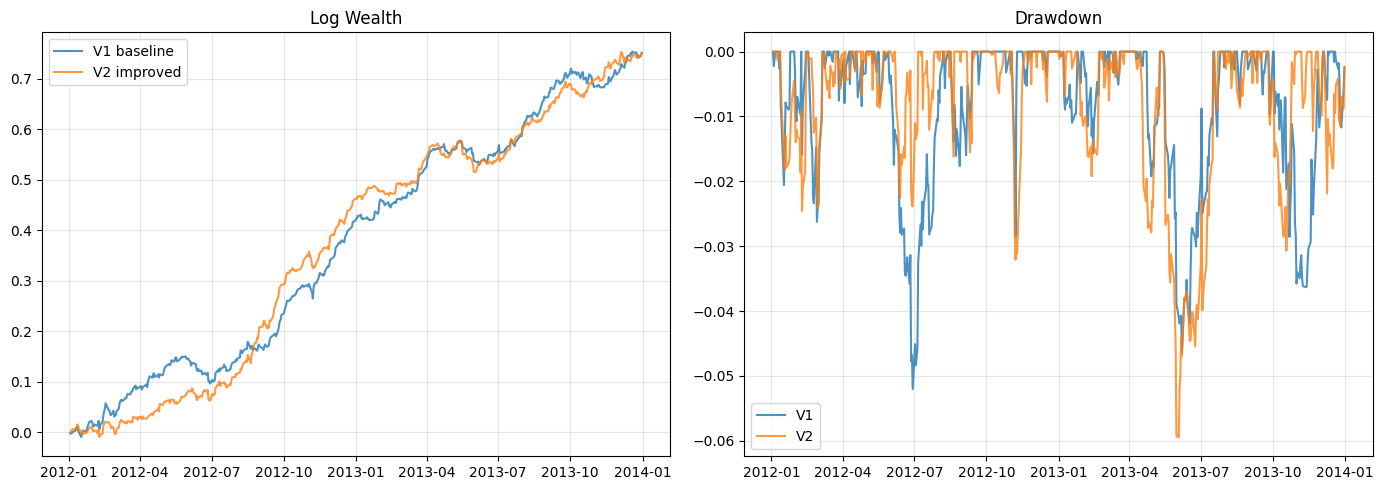

In [43]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
axes[0].plot(w_v1.index, np.log(w_v1['wealth']), label='V1 baseline', alpha=0.8)
axes[0].plot(w_v2.index, np.log(w_v2['wealth']), label='V2 improved', alpha=0.8)
axes[0].set_title('Log Wealth'); axes[0].legend(); axes[0].grid(alpha=0.3)

for label, wdf in [('V1', w_v1), ('V2', w_v2)]:
    dd = wdf['wealth']/wdf['wealth'].cummax() - 1
    axes[1].plot(dd.index, dd, label=label, alpha=0.8)
axes[1].set_title('Drawdown'); axes[1].legend(); axes[1].grid(alpha=0.3)
plt.tight_layout(); plt.show()

## Choose holding period to 5 days (from 15) to test if shorter holding can further boost returns (more responsive to signal changes, but higher turnover).

In [38]:
# ---- V2 with 5d horizon factor selection ----
print("\nRunning V2 factor selection at 5d horizon...")
_, ic_summary_5d = evaluate_factor_rank_ic(df_factor_train, all_factor_cols, forward_days=5)

candidates_5d = ic_summary_5d[ic_summary_5d['abs_ic_ir'] >= 0.05]['factor'].tolist()
factor_corr_5d = compute_factor_corr(df_factor_train, candidates_5d)
selected_5d = greedy_select(ic_summary_5d, factor_corr_5d)

factor_config_5d = {}
for f in selected_5d:
    r = ic_summary_5d[ic_summary_5d['factor'] == f].iloc[0]
    factor_config_5d[f] = {'sign': 1 if r['mean_ic'] > 0 else -1, 'weight': abs(r['ic_ir'])}

print(f"V2 (5d): {len(selected_5d)} factors selected:")
for f, c in factor_config_5d.items():
    r = ic_summary_5d[ic_summary_5d['factor'] == f].iloc[0]
    print(f"  {f:25s}  IC={r['mean_ic']:+.4f}  IC-IR={r['ic_ir']:+.3f}")

w_v2_5d, _ = backtest_daily(
    df_test, compute_composite_scores, {'factor_config': factor_config_5d},
    hold_days=5, long_frac=0.10, short_frac=0.10, scale=1.0, dd_protect=True)


Running V2 factor selection at 5d horizon...
V2 (5d): 8 factors selected:
  mom_126d                   IC=-0.1110  IC-IR=-0.760
  mom_42d                    IC=-0.0913  IC-IR=-0.595
  factor9                    IC=-0.0923  IC-IR=-0.569
  zscore_21d                 IC=+0.0491  IC-IR=+0.302
  factor8                    IC=-0.0506  IC-IR=-0.252
  factor4                    IC=-0.0252  IC-IR=-0.171
  vol_skew_20d               IC=-0.0194  IC-IR=-0.139
  factor4_10d                IC=+0.0185  IC-IR=+0.138


In [44]:
print("=== V1 Baseline ==="); print(s_v1); print()
print("=== V2 Improved_15d ==="); print(s_v2); print()
print("=== V2 Improved_5d ==="); print(perf_stats(w_v2_5d)); print()
print("=== Comparison ===")
print(pd.DataFrame({'V1_baseline': s_v1, 'V2_15d': s_v2, 'V2_5d':perf_stats(w_v2_5d)}).round(4))

=== V1 Baseline ===
total_return    1.121162
log_wealth      0.751464
sharpe          4.423802
mdd            -0.052018
annual_vol      0.086405
dtype: float64

=== V2 Improved_15d ===
total_return    1.119584
log_wealth      0.750720
sharpe          4.356596
mdd            -0.059420
annual_vol      0.087678
dtype: float64

=== V2 Improved_5d ===
total_return    0.996054
log_wealth      0.690672
sharpe          3.891808
mdd            -0.051252
annual_vol      0.090441
dtype: float64

=== Comparison ===
              V1_baseline  V2_15d   V2_5d
total_return       1.1212  1.1196  0.9961
log_wealth         0.7515  0.7507  0.6907
sharpe             4.4238  4.3566  3.8918
mdd               -0.0520 -0.0594 -0.0513
annual_vol         0.0864  0.0877  0.0904


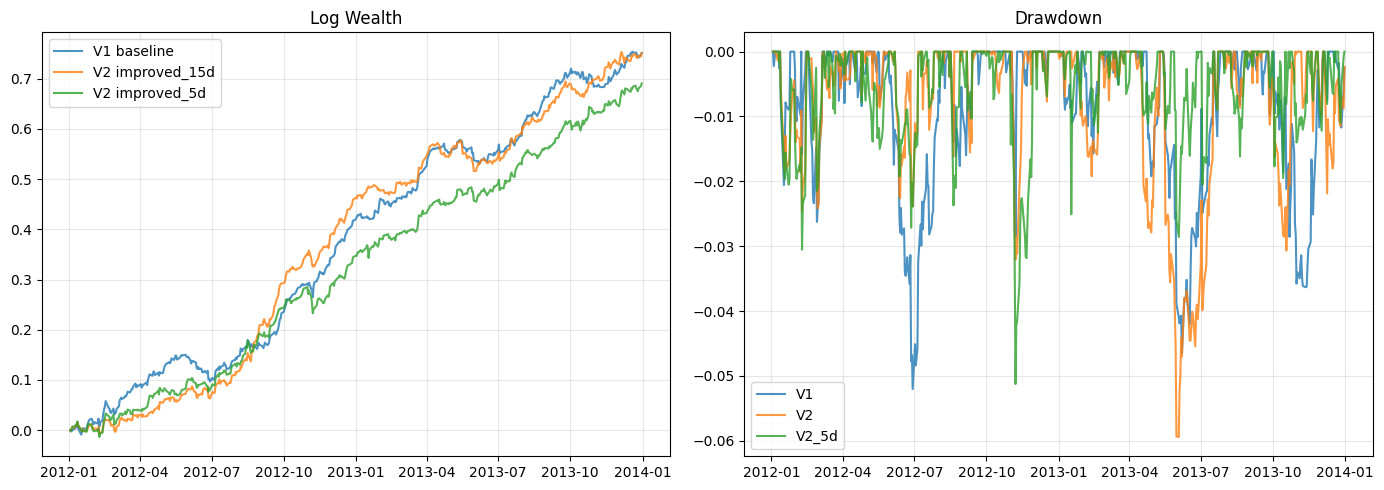

In [45]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
axes[0].plot(w_v1.index, np.log(w_v1['wealth']), label='V1 baseline', alpha=0.8)
axes[0].plot(w_v2.index, np.log(w_v2['wealth']), label='V2 improved_15d', alpha=0.8)
axes[0].plot(w_v2_5d.index, np.log(w_v2_5d['wealth']), label='V2 improved_5d', alpha=0.8)
axes[0].set_title('Log Wealth'); axes[0].legend(); axes[0].grid(alpha=0.3)

for label, wdf in [('V1', w_v1), ('V2', w_v2), ('V2_5d', w_v2_5d)]:
    dd = wdf['wealth']/wdf['wealth'].cummax() - 1
    axes[1].plot(dd.index, dd, label=label, alpha=0.8)
axes[1].set_title('Drawdown'); axes[1].legend(); axes[1].grid(alpha=0.3)
plt.tight_layout(); plt.show()

# Full replication of V1 baseline

In [48]:
# ============================================================
# Four-Way Comparison
# 1. V1 Rank Composite (5 hand-picked factors, equal-weight, hold=5d, basket=20%)
# 2. V1 Ridge (IC>=0.02 screen at 5d, Ridge predict, hold=5d, basket=20%)
# 3. V2 IC-IR Weighted (15d horizon selection, hold=15d, basket=10%, scale=3x)
# 4. V2 IC-IR Weighted (5d horizon selection, hold=5d, basket=10%, scale=3x)
# ============================================================

from sklearn.linear_model import Ridge
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline

# ---- V1 Ridge Baseline ----
v1_all_factors = [c for c in df_factor.columns
                  if c not in ['date','symbol','open','close','low','high','volume','ret']]

df_ridge_train = df_factor[df_factor['date'] < split_date].copy()
df_ridge_train['fwd_ret_5d'] = (
    df_ridge_train.groupby('symbol')['close'].shift(-5) / df_ridge_train['close'] - 1.0
)

v1_ic = {}
for f in v1_all_factors:
    ics = []
    for dt, cross in df_ridge_train.groupby('date'):
        v = cross[[f, 'fwd_ret_5d']].dropna()
        if len(v) >= 10:
            ics.append(v[f].corr(v['fwd_ret_5d'], method='spearman'))
    v1_ic[f] = np.nanmean(ics) if ics else 0.0

v1_ridge_factors = [f for f, ic in v1_ic.items() if abs(ic) >= 0.02]
print(f"V1 Ridge: {len(v1_ridge_factors)} factors selected")

ridge_data = df_ridge_train.dropna(subset=v1_ridge_factors + ['fwd_ret_5d'])
pipe = Pipeline([('scaler', StandardScaler()), ('ridge', Ridge(alpha=1.0))])
pipe.fit(ridge_data[v1_ridge_factors], ridge_data['fwd_ret_5d'])

df_ridge_test = df_factor[df_factor['date'] >= split_date].copy()
df_ridge_test['composite_score'] = pipe.predict(df_ridge_test[v1_ridge_factors].fillna(0))

w_v1_ridge, _ = backtest_daily(
    df_ridge_test,
    composite_func=lambda d, **kw: d,
    composite_kwargs={},
    hold_days=5, long_frac=0.2, short_frac=0.2, scale=1.0, dd_protect=False)

# ---- Collect all results ----
results = {
    'V1 Rank Composite\n(hold=5d, basket=20%, scale=1x)': perf_stats(w_v1),
    'V1 Ridge\n(hold=5d, basket=20%, scale=1x)': perf_stats(w_v1_ridge),
    'V2 (15d select)\n(hold=15d, basket=10%, scale=1x)': perf_stats(w_v2),
    'V2 (5d select)\n(hold=5d, basket=10%, scale=1x)': perf_stats(w_v2_5d),
}

print("\n" + "="*80)
print("FOUR-WAY COMPARISON")
print("="*80)
print(pd.DataFrame(results).T[['log_wealth','sharpe','mdd','annual_vol','total_return']].round(4))

V1 Ridge: 22 factors selected

FOUR-WAY COMPARISON
                                                    log_wealth  sharpe  \
V1 Rank Composite\n(hold=5d, basket=20%, scale=1x)      0.7515  4.4238   
V1 Ridge\n(hold=5d, basket=20%, scale=1x)               0.4307  3.3545   
V2 (15d select)\n(hold=15d, basket=10%, scale=1x)       0.7507  4.3566   
V2 (5d select)\n(hold=5d, basket=10%, scale=1x)         0.6907  3.8918   

                                                       mdd  annual_vol  \
V1 Rank Composite\n(hold=5d, basket=20%, scale=1x) -0.0520      0.0864   
V1 Ridge\n(hold=5d, basket=20%, scale=1x)          -0.0279      0.0653   
V2 (15d select)\n(hold=15d, basket=10%, scale=1x)  -0.0594      0.0877   
V2 (5d select)\n(hold=5d, basket=10%, scale=1x)    -0.0513      0.0904   

                                                    total_return  
V1 Rank Composite\n(hold=5d, basket=20%, scale=1x)        1.1212  
V1 Ridge\n(hold=5d, basket=20%, scale=1x)                 0.5392  
V2 (15

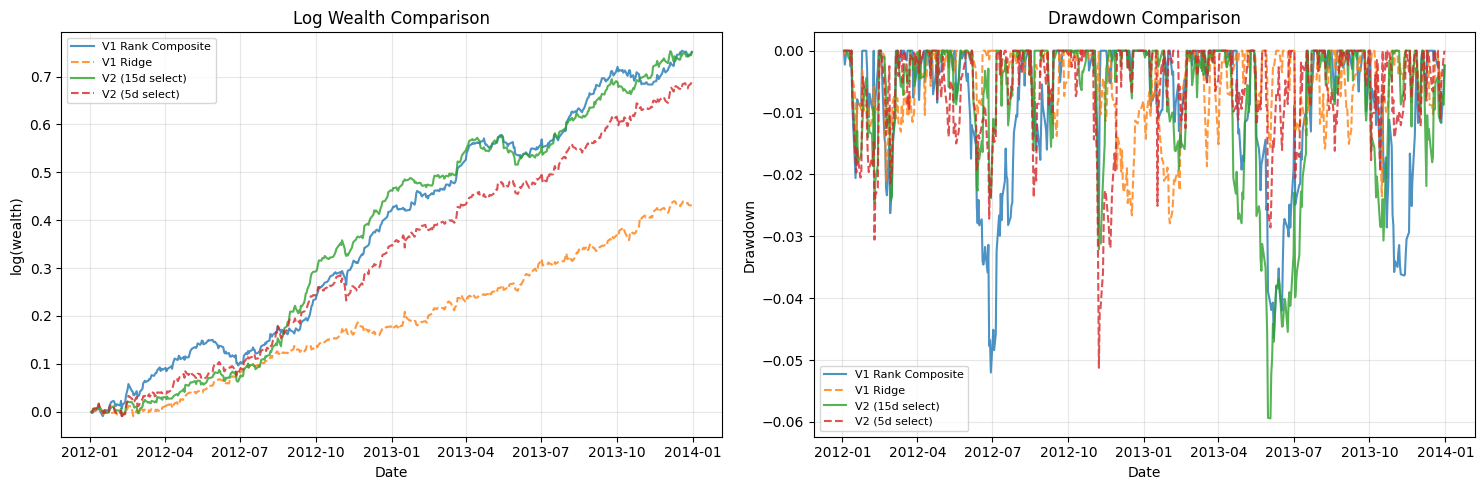


=== Factor selection: 15d vs 5d horizon ===
15d factors: ['mom_126d', 'mom_42d', 'factor9', 'mom_20d', 'factor8', 'vol_skew_20d', 'factor4_10d', 'vol_kurt_60d']
 5d factors: ['mom_126d', 'mom_42d', 'factor9', 'zscore_21d', 'factor8', 'factor4', 'vol_skew_20d', 'factor4_10d']
Overlap: {'mom_42d', 'factor4_10d', 'vol_skew_20d', 'factor9', 'mom_126d', 'factor8'}


In [49]:
# ---- Plot ----
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

ax = axes[0]
styles = [
    ('V1 Rank Composite', w_v1, '-', 'tab:blue'),
    ('V1 Ridge', w_v1_ridge, '--', 'tab:orange'),
    ('V2 (15d select)', w_v2, '-', 'tab:green'),
    ('V2 (5d select)', w_v2_5d, '--', 'tab:red'),
]
for label, wdf, ls, color in styles:
    ax.plot(wdf.index, np.log(wdf['wealth']), label=label, linestyle=ls, color=color, alpha=0.8)
ax.set_title('Log Wealth Comparison')
ax.set_xlabel('Date'); ax.set_ylabel('log(wealth)')
ax.legend(fontsize=8); ax.grid(alpha=0.3)

ax = axes[1]
for label, wdf, ls, color in styles:
    dd = wdf['wealth'] / wdf['wealth'].cummax() - 1
    ax.plot(dd.index, dd, label=label, linestyle=ls, color=color, alpha=0.8)
ax.set_title('Drawdown Comparison')
ax.set_xlabel('Date'); ax.set_ylabel('Drawdown')
ax.legend(fontsize=8); ax.grid(alpha=0.3)

plt.tight_layout()
plt.show()

# ---- Also show: V2 (5d) vs V2 (15d) factor selection differences ----
print("\n=== Factor selection: 15d vs 5d horizon ===")
print(f"15d factors: {list(factor_config.keys())}")
print(f" 5d factors: {list(factor_config_5d.keys())}")
overlap = set(factor_config.keys()) & set(factor_config_5d.keys())
print(f"Overlap: {overlap if overlap else 'none'}")

## Ablation Study

In [11]:
abl = {}
abl['V1 baseline'] = s_v1

w, _ = backtest_daily(df_test, compute_composite_scores, {'factor_config': factor_config},
                       hold_days=5, long_frac=0.2, short_frac=0.2, scale=1.0)
abl['+ V2 signal'] = perf_stats(w)

w, _ = backtest_daily(df_test, compute_composite_scores, {'factor_config': factor_config},
                       hold_days=15, long_frac=0.2, short_frac=0.2, scale=1.0)
abl['+ hold=15d'] = perf_stats(w)

w, _ = backtest_daily(df_test, compute_composite_scores, {'factor_config': factor_config},
                       hold_days=15, long_frac=0.10, short_frac=0.10, scale=1.0)
abl['+ basket=10%'] = perf_stats(w)

w, _ = backtest_daily(df_test, compute_composite_scores, {'factor_config': factor_config},
                       hold_days=15, long_frac=0.10, short_frac=0.10, scale=3.0)
abl['+ scale=3x'] = perf_stats(w)

abl['+ DD protect (V2)'] = s_v2

print(pd.DataFrame(abl).T[['log_wealth','sharpe','mdd','annual_vol']].round(4))

                   log_wealth  sharpe     mdd  annual_vol
V1 baseline            0.6259  5.0736 -0.0310      0.0625
+ V2 signal            0.4945  3.6637 -0.0375      0.0686
+ hold=15d             0.6030  4.6367 -0.0372      0.0660
+ basket=10%           0.7507  4.3566 -0.0594      0.0877
+ scale=3x             2.2208  4.3901 -0.1691      0.2630
+ DD protect (V2)      2.1187  4.4718 -0.1189      0.2457


## IC Stability: Train vs Test

=== IC-IR Stability ===
      factor  mean_ic_train  ic_ir_train  mean_ic_test  ic_ir_test
    mom_126d      -0.175285    -1.477611     -0.196304   -1.420879
idio_mom_42d      -0.161526    -1.018781     -0.175258   -1.232798
     factor9      -0.155700    -0.941815     -0.132613   -0.708531
     mom_20d      -0.111913    -0.714340     -0.107617   -0.556451
     factor8      -0.088165    -0.481474     -0.124941   -0.540045
vol_skew_20d      -0.043071    -0.320502     -0.039479   -0.257639
 factor4_10d       0.044659     0.296553     -0.008072   -0.053435
vol_kurt_60d       0.035778     0.247551      0.008393    0.069863


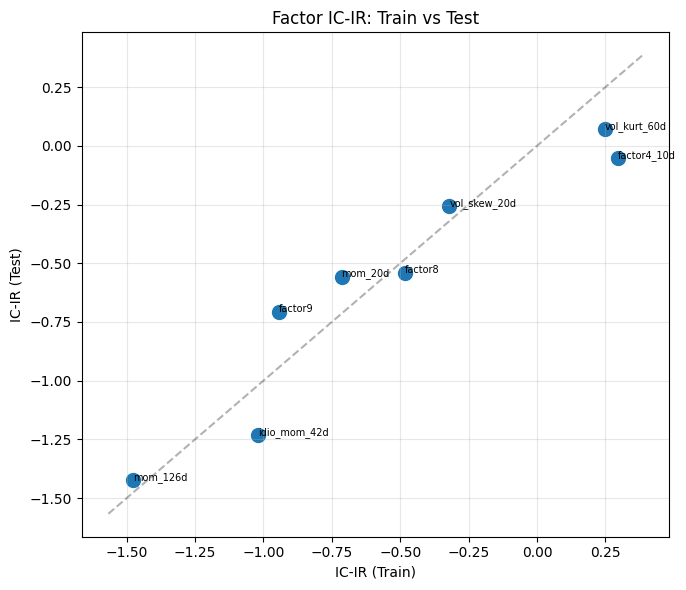

In [12]:
df_test_full = df_factor[df_factor['date'] >= split_date].copy()
_, ic_test = evaluate_factor_rank_ic(df_test_full, selected_factors, forward_days=15)
_, ic_train = evaluate_factor_rank_ic(df_factor_train, selected_factors, forward_days=15)

stab = ic_train[['factor','mean_ic','ic_ir']].merge(
    ic_test[['factor','mean_ic','ic_ir']], on='factor', suffixes=('_train','_test'))
print("=== IC-IR Stability ===")
print(stab.to_string(index=False))

fig, ax = plt.subplots(figsize=(7,6))
ax.scatter(stab['ic_ir_train'], stab['ic_ir_test'], s=100)
for _, row in stab.iterrows():
    ax.annotate(row['factor'], (row['ic_ir_train'], row['ic_ir_test']), fontsize=7)
lims = [min(ax.get_xlim()[0], ax.get_ylim()[0]), max(ax.get_xlim()[1], ax.get_ylim()[1])]
ax.plot(lims, lims, 'k--', alpha=0.3)
ax.set_xlabel('IC-IR (Train)'); ax.set_ylabel('IC-IR (Test)')
ax.set_title('Factor IC-IR: Train vs Test'); ax.grid(alpha=0.3)
plt.tight_layout(); plt.show()